In [2]:
# Domain Adaptation Model Testing Notebook
# Load and test trained DA models with comprehensive evaluation

import sys
sys.path.append("..")
import os

import torch
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence, pack_sequence, pack_padded_sequence, unpack_sequence
import numpy as np
import yaml
import pandas as pd# 0. Experiment selection
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from tqdm import tqdm

from copy import deepcopy

from src.models.base_models import create_model
from src.models.domain_discriminator import DomainDiscriminator, create_da_model
from src.data.numu_dataset import NuMuDataset, create_numu_dataloader_from_ds

In [3]:
torch.cuda.is_available()

True

# No DA

## Preparation

In [4]:
# Set up paths and experiment
EXPERIMENT_DIR = Path("../experiments/numu/da_numu_251112_small_tinylambdasmallddnoreg_aug_newlr")
DEVICE = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

print(f"Testing experiment: {EXPERIMENT_DIR.name}")
print(f"Device: {DEVICE}")

SAVING_POSTFIX = "BigMCSample_EqualAtmAtsro"

report_dir = f"{EXPERIMENT_DIR}/report_{SAVING_POSTFIX}"
os.makedirs(report_dir, exist_ok=True)

fig_dir = f"{report_dir}/figures/"
os.makedirs(fig_dir, exist_ok=True)

# Load configuration files
config_path = EXPERIMENT_DIR / "da_config.yaml"
norm_config_path = EXPERIMENT_DIR / "normalization_config.yaml"

with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

with open(norm_config_path, 'r') as f:
    normalization_config = yaml.safe_load(f)
    
# Load models
## Load trained models from best checkpoint
checkpoint_path = EXPERIMENT_DIR / "best_da_model.pth"
print(f"Loading checkpoint from: {checkpoint_path}")
checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
## Create and load base model
model = create_model(config['model'])
model.load_state_dict(checkpoint['base_model_state_dict'])
model.to(DEVICE)
model.eval()
## Create and load domain discriminator
feature_dim = config['model']['feature_extractor']['d_model']
domain_discriminator = DomainDiscriminator(
    input_dim=feature_dim,
    **config['domain_adaptation']['domain_discriminator']
)
domain_discriminator.load_state_dict(checkpoint['domain_discriminator_state_dict'])
domain_discriminator.to(DEVICE)
domain_discriminator.eval()

Testing experiment: da_numu_251112_small_tinylambdasmallddnoreg_aug_newlr
Device: cuda:1
Loading checkpoint from: ../experiments/numu/da_numu_251112_small_tinylambdasmallddnoreg_aug_newlr/best_da_model.pth


DomainDiscriminator(
  (gradient_reversal): GradientReversalLayer()
  (discriminator): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [5]:
torch.cuda.is_available()

True

In [6]:
# Load datasets

# MC
## Create test dataset (using source domain for classification evaluation)
source_config = config['data']['source_domain']
train_events_per_particle = config['data']['source_domain']['events_per_particle']
## Use validation portion of source data for testing (events model hasn't seen)
mc_dataset = NuMuDataset(
    h5_path=source_config['h5_path'],
    events_per_particle={'muatm_2020': 500_000, 'nue2_2020': 250_000, 'nuatm_2020': 250_000},  # Test portion
    particle_types=source_config['particle_types'],
    neutrino_types=source_config['neutrino_types'],
    max_hits=config['data']['max_hits'],
    sampling_config={
        'muatm_2020': {'mode': 'range', 'start_event': train_events_per_particle['muatm_2020']},
        'nue2_2020': {'mode': 'range', 'start_event': train_events_per_particle['nue2_2020']},
        'nuatm_2020': {'mode': 'range', 'start_event': train_events_per_particle['nuatm_2020']}
        },
    device=DEVICE,
    shuffle_events=False
)
## Create test dataloader
mc_dataloader = create_numu_dataloader_from_ds(
    dataset=mc_dataset,
    batch_size=256,
    normalization_config=normalization_config,
    augmentation_config=None,  # No augmentation for testing
    num_workers=0,
    shuffle=True,
    shuffle_batch=False
)
print(f"Test dataloader created:")
print(f"- Batch size: {mc_dataloader.batch_size}")
print(f"- Number of batches: {len(mc_dataloader)}")
print(f"- Total events: {len(mc_dataset)}")
print(f"- Normalization: {normalization_config['feature_names']}")
print(f"- Means: {normalization_config['means']}")
print(f"- Stds: {normalization_config['stds']}")

# EXP
## Create a sample of target domain data for domain discrimination test
target_config = config['data']['target_domain']
target_dataset = NuMuDataset(
    h5_path=target_config['h5_path'],
    particle_types=target_config['particle_types'],
    neutrino_types=target_config.get('neutrino_types', []),
    sampling_config={
        'exp': {
            'mode': 'range', 'start_event': target_config['events_per_particle']['exp']
                }},
    events_per_particle={'exp': 500_000},  # Small sample
    max_hits=config['data']['max_hits'],
    device=DEVICE,
    shuffle_events=False
)
target_dataloader = create_numu_dataloader_from_ds(
    dataset=target_dataset,
    batch_size=256,
    normalization_config=normalization_config,
    shuffle_batch=False,
    augmentation_config=None,
    num_workers=0,
    shuffle=False
)

print(f"Target Test dataloader created:")
print(f"- Batch size: {target_dataloader.batch_size}")
print(f"- Number of batches: {len(target_dataloader)}")
print(f"- Total events: {len(target_dataset)}")

Test dataloader created:
- Batch size: 256
- Number of batches: 3907
- Total events: 1000000
- Normalization: ['amplitude', 'time', 'x', 'y', 'z']
- Means: [2.0, 0.0, 0.0, 0.0, 0.0]
- Stds: [60.0, 1370.0, 40.0, 40.0, 150.0]
Target Test dataloader created:
- Batch size: 256
- Number of batches: 1368
- Total events: 349976


In [7]:
# Make preds and Collect stats

# MC
mc_raw_data = []
mc_predictions = []
mc_probabilities = []
mc_labels = []
mc_features = []
mc_magic_numbers = []
mc_channels_ids = []
mc_dd_probs = []
batch_num = 0
with torch.no_grad():
    for batch in tqdm(mc_dataloader, miniters=50, desc='For MC dataset'):
        # Get feature representations and predictions
        feature_repr = model.get_feature_representation(batch)
        logits = model.classifier(feature_repr)
        dd_logits = domain_discriminator(feature_repr)
        probabilities_batch = torch.sigmoid(logits)
        dd_probs_batch = torch.sigmoid(dd_logits)
        predictions_batch = (probabilities_batch > 0.5).float()
        
        # Store results
        mc_features.append(feature_repr.cpu())
        mc_predictions.append(predictions_batch.cpu())
        mc_probabilities.append(probabilities_batch.cpu())
        mc_dd_probs.append(dd_probs_batch.cpu())
        mc_labels.append(batch['labels'].cpu())
        mc_magic_numbers.extend(batch['magic_numbers'])
        mc_channels_ids.extend(batch['channels_ids'])
        
        # Raw features
        packed_seq_raw_data_batch = pack_padded_sequence(
            batch['features'].cpu(), batch['lengths'].cpu(), 
            batch_first=True, enforce_sorted=False
            )
        mc_raw_data.extend([t.numpy() for t in unpack_sequence(packed_seq_raw_data_batch)])
        # if batch_num>500:
        #     break
        batch_num += 1
## Concatenate all results
mc_features = torch.cat(mc_features, dim=0).numpy()
mc_predictions = torch.cat(mc_predictions, dim=0).numpy().flatten()
mc_probabilities = torch.cat(mc_probabilities, dim=0).numpy().flatten()
mc_labels = torch.cat(mc_labels, dim=0).numpy().flatten()
mc_dd_probs = torch.cat(mc_dd_probs, dim=0).numpy().flatten()


# EXP
exp_raw_data = []
exp_predictions = []
exp_probabilities = []
exp_features = []
exp_channels_ids = []
exp_dd_probs = []
print()
batch_num = 0
with torch.no_grad():
    for batch in tqdm(target_dataloader, miniters=50, desc="For EXP (target) dataset"):
        # Get feature representations and predictions
        feature_repr = model.get_feature_representation(batch)
        logits = model.classifier(feature_repr)
        dd_logits = domain_discriminator(feature_repr)
        probabilities_batch = torch.sigmoid(logits)
        dd_probs_batch = torch.sigmoid(dd_logits)
        predictions_batch = (probabilities_batch > 0.5).float()
        
        # Store results
        exp_features.append(feature_repr.cpu())
        exp_predictions.append(predictions_batch.cpu())
        exp_probabilities.append(probabilities_batch.cpu())
        exp_dd_probs.append(dd_probs_batch.cpu())
        exp_channels_ids.extend(batch['channels_ids'])
        
        # Raw features
        packed_seq_raw_data_batch = pack_padded_sequence(
            batch['features'].cpu(), batch['lengths'].cpu(), 
            batch_first=True, enforce_sorted=False
            )
        exp_raw_data.extend([t.numpy() for t in unpack_sequence(packed_seq_raw_data_batch)])
        # if batch_num>500:
        #     break
        batch_num += 1
## Concatenate all results
exp_features = torch.cat(exp_features, dim=0).numpy()
exp_predictions = torch.cat(exp_predictions, dim=0).numpy().flatten()
exp_probabilities = torch.cat(exp_probabilities, dim=0).numpy().flatten()
exp_dd_probs = torch.cat(exp_dd_probs, dim=0).numpy().flatten()

For MC dataset:   0%|          | 0/3907 [00:00<?, ?it/s]/home/albert/miniconda3/envs/baikal25/lib/python3.10/site-packages/torch/nn/modules/transformer.py:508: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(
For MC dataset: 100%|██████████| 3907/3907 [01:41<00:00, 38.31it/s]


For EXP (target) dataset: 100%|██████████| 1368/1368 [00:32<00:00, 42.07it/s]


# DA

In [32]:
# Set up paths and experiment
EXPERIMENT_DIR_DA = Path("../experiments/numu/da_numu_251123_small_moderatelambdmidddnoreg_aug_newlr")
DEVICE = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

print(f"Testing experiment: {EXPERIMENT_DIR_DA.name}")
print(f"Device: {DEVICE}")

SAVING_POSTFIX = "BigMCSample_EqualAtmAtsro"

report_dir = f"{EXPERIMENT_DIR_DA}/report_{SAVING_POSTFIX}"
os.makedirs(report_dir, exist_ok=True)

fig_dir = f"{report_dir}/figures/"
os.makedirs(fig_dir, exist_ok=True)

# Load configuration files
config_path = EXPERIMENT_DIR_DA / "da_config.yaml"
norm_config_path = EXPERIMENT_DIR_DA / "normalization_config.yaml"

with open(config_path, 'r') as f:
    config_da = yaml.safe_load(f)

with open(norm_config_path, 'r') as f:
    normalization_config_da = yaml.safe_load(f)
    
# Load models
## Load trained models from best checkpoint
checkpoint_path = EXPERIMENT_DIR_DA / "best_da_model.pth"
print(f"Loading checkpoint from: {checkpoint_path}")
checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
## Create and load base model
model_da = create_model(config_da['model'])
model_da.load_state_dict(checkpoint['base_model_state_dict'])
model_da.to(DEVICE)
model_da.eval()
## Create and load domain discriminator
feature_dim = config_da['model']['feature_extractor']['d_model']
domain_discriminator_da = DomainDiscriminator(
    input_dim=feature_dim,
    **config_da['domain_adaptation']['domain_discriminator']
)
domain_discriminator_da.load_state_dict(checkpoint['domain_discriminator_state_dict'])
domain_discriminator_da.to(DEVICE)
domain_discriminator_da.eval()

Testing experiment: da_numu_251123_small_moderatelambdmidddnoreg_aug_newlr
Device: cuda:1
Loading checkpoint from: ../experiments/numu/da_numu_251123_small_moderatelambdmidddnoreg_aug_newlr/best_da_model.pth


DomainDiscriminator(
  (gradient_reversal): GradientReversalLayer()
  (discriminator): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.0, inplace=False)
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [33]:
# Load datasets DA

# MC
## Create test dataset (using source domain for classification evaluation)
source_config_da = config_da['data']['source_domain']
train_events_per_particle_da = config_da['data']['source_domain']['events_per_particle']
## Use validation portion of source data for testing (events model hasn't seen)
mc_dataset_da = NuMuDataset(
    h5_path=source_config_da['h5_path'],
    events_per_particle={'muatm_2020': 500_000, 'nue2_2020': 250_000, 'nuatm_2020': 250_000},  # Test portion
    particle_types=source_config_da['particle_types'],
    neutrino_types=source_config_da['neutrino_types'],
    max_hits=config['data']['max_hits'],
    sampling_config={
        'muatm_2020': {'mode': 'range', 'start_event': train_events_per_particle_da['muatm_2020']},
        'nue2_2020': {'mode': 'range', 'start_event': train_events_per_particle_da['nue2_2020']},
        'nuatm_2020': {'mode': 'range', 'start_event': train_events_per_particle_da['nuatm_2020']}
        },
    device=DEVICE,
    shuffle_events=False
)
## Create test dataloader
mc_dataloader_da = create_numu_dataloader_from_ds(
    dataset=mc_dataset_da,
    batch_size=256,
    normalization_config=normalization_config_da,
    augmentation_config=None,  # No augmentation for testing
    num_workers=0,
    shuffle=True,
    shuffle_batch=False
)
print(f"Test dataloader created:")
print(f"- Batch size: {mc_dataloader_da.batch_size}")
print(f"- Number of batches: {len(mc_dataloader_da)}")
print(f"- Total events: {len(mc_dataset_da)}")
print(f"- Normalization: {normalization_config_da['feature_names']}")
print(f"- Means: {normalization_config_da['means']}")
print(f"- Stds: {normalization_config_da['stds']}")

# EXP
## Create a sample of target domain data for domain discrimination test
target_config_da = config_da['data']['target_domain']
target_dataset_da = NuMuDataset(
    h5_path=target_config_da['h5_path'],
    particle_types=target_config_da['particle_types'],
    neutrino_types=target_config_da.get('neutrino_types', []),
    sampling_config={
        'exp': {
            'mode': 'range', 'start_event': target_config_da['events_per_particle']['exp']
                }},
    events_per_particle={'exp': 500_000},  # Small sample
    max_hits=config_da['data']['max_hits'],
    device=DEVICE,
    shuffle_events=False
)
target_dataloader_da = create_numu_dataloader_from_ds(
    dataset=target_dataset_da,
    batch_size=256,
    normalization_config=normalization_config_da,
    shuffle_batch=False,
    augmentation_config=None,
    num_workers=0,
    shuffle=False
)

print(f"Target Test dataloader created:")
print(f"- Batch size: {target_dataloader_da.batch_size}")
print(f"- Number of batches: {len(target_dataloader_da)}")
print(f"- Total events: {len(target_dataset_da)}")

Test dataloader created:
- Batch size: 256
- Number of batches: 3907
- Total events: 1000000
- Normalization: ['amplitude', 'time', 'x', 'y', 'z']
- Means: [2.0, 0.0, 0.0, 0.0, 0.0]
- Stds: [60.0, 1370.0, 40.0, 40.0, 150.0]
Target Test dataloader created:
- Batch size: 256
- Number of batches: 1368
- Total events: 349976


In [34]:
# Make preds and Collect stats

# MC DA
mc_raw_data_da = []
mc_predictions_da = []
mc_probabilities_da = []
mc_labels_da = []
mc_features_da = []
mc_magic_numbers_da = []
mc_channels_ids_da = []
mc_dd_probs_da = []
batch_num = 0
with torch.no_grad():
    for batch in tqdm(mc_dataloader_da, miniters=50, desc='For MC dataset'):
        # Get feature representations and predictions
        feature_repr = model_da.get_feature_representation(batch)
        logits = model_da.classifier(feature_repr)
        dd_logits = domain_discriminator_da(feature_repr)
        probabilities_batch = torch.sigmoid(logits)
        dd_probs_batch = torch.sigmoid(dd_logits)
        predictions_batch = (probabilities_batch > 0.5).float()
        
        # Store results
        mc_features_da.append(feature_repr.cpu())
        mc_predictions_da.append(predictions_batch.cpu())
        mc_probabilities_da.append(probabilities_batch.cpu())
        mc_dd_probs_da.append(dd_probs_batch.cpu())
        mc_labels_da.append(batch['labels'].cpu())
        mc_magic_numbers_da.extend(batch['magic_numbers'])
        mc_channels_ids_da.extend(batch['channels_ids'])
        
        # Raw features
        packed_seq_raw_data_batch = pack_padded_sequence(
            batch['features'].cpu(), batch['lengths'].cpu(), 
            batch_first=True, enforce_sorted=False
            )
        mc_raw_data_da.extend([t.numpy() for t in unpack_sequence(packed_seq_raw_data_batch)])
        # if batch_num>500:
        #     break
        batch_num += 1
## Concatenate all results
mc_features_da = torch.cat(mc_features_da, dim=0).numpy()
mc_predictions_da = torch.cat(mc_predictions_da, dim=0).numpy().flatten()
mc_probabilities_da = torch.cat(mc_probabilities_da, dim=0).numpy().flatten()
mc_labels_da = torch.cat(mc_labels_da, dim=0).numpy().flatten()
mc_dd_probs_da = torch.cat(mc_dd_probs_da, dim=0).numpy().flatten()


# EXP DA
exp_raw_data_da = []
exp_predictions_da = []
exp_probabilities_da = []
exp_features_da = []
exp_channels_ids_da = []
exp_dd_probs_da = []
print()
batch_num = 0
with torch.no_grad():
    for batch in tqdm(target_dataloader, miniters=50, desc="For EXP (target) dataset"):
        # Get feature representations and predictions
        feature_repr = model_da.get_feature_representation(batch)
        logits = model_da.classifier(feature_repr)
        dd_logits = domain_discriminator_da(feature_repr)
        probabilities_batch = torch.sigmoid(logits)
        dd_probs_batch = torch.sigmoid(dd_logits)
        predictions_batch = (probabilities_batch > 0.5).float()
        
        # Store results
        exp_features_da.append(feature_repr.cpu())
        exp_predictions_da.append(predictions_batch.cpu())
        exp_probabilities_da.append(probabilities_batch.cpu())
        exp_dd_probs_da.append(dd_probs_batch.cpu())
        exp_channels_ids_da.extend(batch['channels_ids'])
        
        # Raw features
        packed_seq_raw_data_batch = pack_padded_sequence(
            batch['features'].cpu(), batch['lengths'].cpu(), 
            batch_first=True, enforce_sorted=False
            )
        exp_raw_data_da.extend([t.numpy() for t in unpack_sequence(packed_seq_raw_data_batch)])
        # if batch_num>500:
        #     break
        batch_num += 1
## Concatenate all results
exp_features_da = torch.cat(exp_features_da, dim=0).numpy()
exp_predictions_da = torch.cat(exp_predictions_da, dim=0).numpy().flatten()
exp_probabilities_da = torch.cat(exp_probabilities_da, dim=0).numpy().flatten()
exp_dd_probs_da = torch.cat(exp_dd_probs_da, dim=0).numpy().flatten()

For MC dataset: 100%|██████████| 3907/3907 [01:47<00:00, 36.21it/s]


For EXP (target) dataset: 100%|██████████| 1368/1368 [00:33<00:00, 40.49it/s]


# Reco data loading

In [1]:
import h5py
import uproot as ur
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('../../Baikal-ML')


from data.root_extractor.internal_root_paths import ExpRecoRootPaths
from data.root_extractor.main import RootFileReader

In [2]:
# data
names = [
        '2020/2020_cl3_run124_scl_DATA2020',
        '2020/2020_cl3_run123_scl_DATA2020',
        '2020/2020_cl3_run126_scl_DATA2020',
        '2020/2020_cl3_run128_scl_DATA2020',
        '2020/2020_cl3_run127_scl_DATA2020',
        '2020/2020_cl3_run120_scl_DATA2020',
        '2020/2020_cl3_run121_scl_nu_DATA2020',
        '2020/2020_cl3_run129_scl_DATA2020',
        '2020/2020_cl3_run125_scl_DATA2020',
        '2020/2020_cl3_run122_scl_DATA2020',
        '2020/2020_cl3_run121_scl_DATA2020'
        ]
reco_paths = [f"/net/62/home3/ivkhar/Baikal/data/initial_data/exp_data/{name}.root" for name in names]

norm_params = {
    'means': [2., 0., 0., 0., 0.],
    'stds': [60., 1370., 40., 40., 150.],
    'feature_names': ['amplitude', 'time', 'x', 'y', 'z']
}

In [3]:
cl3_centers = [-278.94, -97.17, 362.4]    

pulses_df = []
om_coords = []
events_df = []
for i, path in enumerate(reco_paths):
    with RootFileReader(path, ExpRecoRootPaths(), prefix=f"{i}_") as rr:
        events_df.append(rr.read_events_as_df())
        pulses_df.append(rr.read_pulses_as_df().to_pandas())
        #muons = rr.read_muons_as_df()
        om_coords.append(rr.read_OM_coords().to_pandas())
print(pulses_df)
pulses_df_pd = pd.concat(pulses_df, axis=0)
om_coords_pd = pd.concat(om_coords, axis=0)

exp_reco_df0 = pulses_df_pd.merge(om_coords_pd[['X','Y','Z','PulsesChID','ev_id']], how='left', on=['ev_id', 'PulsesChID']).dropna()
# Centering cluster
exp_reco_df0['X'] = exp_reco_df0['X'] - cl3_centers[0]
exp_reco_df0['Y'] = exp_reco_df0['Y'] - cl3_centers[1]
exp_reco_df0['Z'] = exp_reco_df0['Z'] - cl3_centers[2]
# Center times
times_centers = exp_reco_df0[['ev_id', 'PulsesTime']].groupby('ev_id').agg('mean').rename(columns={'PulsesTime': 't_center'})
exp_reco_df0 = exp_reco_df0.merge(times_centers, how='left', on='ev_id')
# Norm data
exp_reco_df0['PulsesTime'] = exp_reco_df0['PulsesTime'] - exp_reco_df0['t_center']
for i, col in enumerate(['PulsesAmpl', 'PulsesTime', 'X', 'Y', 'Z']):
    exp_reco_df0[col] = (exp_reco_df0[col] - norm_params['means'][i])/norm_params['stds'][i]
# Agg data
exp_reco_df0['input_features'] = exp_reco_df0[['PulsesAmpl', 'PulsesTime', 'X', 'Y', 'Z']].agg(np.array, axis=1)

[        PulsesChID  PulsesAmpl    PulsesTime  PulsesTrueAmpl  SignalFlg  \
0              NaN         NaN           NaN             NaN        NaN   
1             12.0    1.032679  15170.885742       29.199951        0.0   
2             21.0    1.664925  16057.341797       43.708984        1.0   
3             23.0    0.918112  15935.164062       27.798828        0.0   
4             26.0    1.204309  17202.148438       33.270508        0.0   
...            ...         ...           ...             ...        ...   
172866       282.0    0.550675  16220.062500       16.199219        0.0   
172867       283.0    1.407609  16193.700195       37.800781        0.0   
172868       284.0    1.942234  16063.183594       32.699219        0.0   
172869       286.0    1.493142  16037.455078       38.000000        0.0   
172870       287.0    5.191317  15927.396484      120.300781        0.0   

         ev_id  
0          0_0  
1          0_1  
2          0_1  
3          0_1  
4          0_

In [58]:
len(pulses_df_pd['ev_id'].unique())

27530

In [17]:
exp_reco_df = exp_reco_df0[['ev_id', 'SignalFlg', 'input_features']].groupby('ev_id').aggregate(
    {'SignalFlg': 'sum', 'input_features': list}
    ).rename(columns={'SignalFlg': 'sig_hits_num'})
# Sort times within 1 event
exp_reco_df['input_features'] = exp_reco_df['input_features'].apply(lambda x: sorted(x, key=lambda arr: arr[1]))

## No DA

In [18]:
start = 0
step = 256
reco_raw_data = []
reco_predictions = []
reco_probabilities = []
reco_features = []
reco_channels_ids = []
reco_dd_probs = []
reco_sig_hits_num = []
batch_num = 0
with torch.no_grad():
    while start<len(exp_reco_df):
        batch_data = exp_reco_df['input_features'].iloc[start:start+step]
        exp_raw_data.extend(batch_data)
        lengths = torch.tensor([len(arr) for arr in batch_data], dtype=int, device=DEVICE)
        batch_data = [torch.tensor(arr, device=DEVICE, dtype=torch.float32) for arr in batch_data]
        reco_sig_hits_num.extend(exp_reco_df['sig_hits_num'].iloc[start:start+step])
        mask = pad_sequence([torch.ones(l, dtype=bool, device=DEVICE) for l in lengths], batch_first=True)
        data_pad = pad_sequence(batch_data, batch_first=True)
        batch = {}
        batch['features'] = data_pad
        batch['mask'] = mask
        batch['lengths'] = lengths
        
        feature_repr = model.get_feature_representation(batch)
        logits = model.classifier(feature_repr)
        dd_logits = domain_discriminator(feature_repr)
        probabilities_batch = torch.sigmoid(logits)
        dd_probs_batch = torch.sigmoid(dd_logits)
        predictions_batch = (probabilities_batch > 0.5).float()
        
        # Store results
        reco_features.append(feature_repr.cpu())
        reco_predictions.append(predictions_batch.cpu())
        reco_probabilities.append(probabilities_batch.cpu())
        reco_dd_probs.append(dd_probs_batch.cpu())

        # if batch_num>500:
        #     break
        batch_num += 1
        start += step

## Concatenate all results
reco_features = torch.cat(reco_features, dim=0).numpy()
reco_predictions = torch.cat(reco_predictions, dim=0).numpy().flatten()
reco_probabilities = torch.cat(reco_probabilities, dim=0).numpy().flatten()
reco_dd_probs = torch.cat(reco_dd_probs, dim=0).numpy().flatten()
reco_sig_hits_num = np.array(reco_sig_hits_num)

/tmp/ipykernel_2578849/3490652268.py:16: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  batch_data = [torch.tensor(arr, device=DEVICE, dtype=torch.float32) for arr in batch_data]


## DA

In [35]:
start = 0
step = 256
reco_raw_data_da = []
reco_predictions_da = []
reco_probabilities_da = []
reco_features_da = []
reco_channels_ids_da = []
reco_dd_probs_da = []
reco_sig_hits_num_da = []
batch_num = 0
with torch.no_grad():
    while start<len(exp_reco_df):
        batch_data = exp_reco_df['input_features'].iloc[start:start+step]
        reco_raw_data_da.extend(batch_data)
        lengths = torch.tensor([len(arr) for arr in batch_data], dtype=int, device=DEVICE)
        batch_data = [torch.tensor(arr, device=DEVICE, dtype=torch.float32) for arr in batch_data]
        reco_sig_hits_num_da.extend(exp_reco_df['sig_hits_num'].iloc[start:start+step])
        mask = pad_sequence([torch.ones(l, dtype=bool, device=DEVICE) for l in lengths], batch_first=True)
        data_pad = pad_sequence(batch_data, batch_first=True)
        batch = {}
        batch['features'] = data_pad
        batch['mask'] = mask
        batch['lengths'] = lengths
        
        feature_repr = model_da.get_feature_representation(batch)
        logits = model_da.classifier(feature_repr)
        dd_logits = domain_discriminator_da(feature_repr)
        probabilities_batch = torch.sigmoid(logits)
        dd_probs_batch = torch.sigmoid(dd_logits)
        predictions_batch = (probabilities_batch > 0.5).float()
        
        # Store results
        reco_features_da.append(feature_repr.cpu())
        reco_predictions_da.append(predictions_batch.cpu())
        reco_probabilities_da.append(probabilities_batch.cpu())
        reco_dd_probs_da.append(dd_probs_batch.cpu())

        # if batch_num>500:
        #     break
        batch_num += 1
        start += step

## Concatenate all results
reco_features_da = torch.cat(reco_features_da, dim=0).numpy()
reco_predictions_da = torch.cat(reco_predictions_da, dim=0).numpy().flatten()
reco_probabilities_da = torch.cat(reco_probabilities_da, dim=0).numpy().flatten()
reco_dd_probs_da = torch.cat(reco_dd_probs_da, dim=0).numpy().flatten()
reco_sig_hits_num_da = np.array(reco_sig_hits_num_da)

# Plots

In [36]:
mc_signal_hit_nums = np.asarray([(numbers!=0).sum() for numbers in mc_magic_numbers])
mc_signal_string_nums = np.asarray([np.unique(ids[numbers!=0]//36).size for numbers, ids in zip(mc_magic_numbers, mc_channels_ids)])

In [37]:
mc_signal_hit_nums_da = np.asarray([(numbers!=0).sum() for numbers in mc_magic_numbers_da])
mc_signal_string_nums_da = np.asarray([np.unique(ids[numbers!=0]//36).size for numbers, ids in zip(mc_magic_numbers_da, mc_channels_ids_da)])

KL(MC || EXP) = 0.00459846
KL(EXP || MC) = 0.00456601
DA KL(MC || EXP) = 0.00281913
DA KL(EXP || MC) = 0.00257825


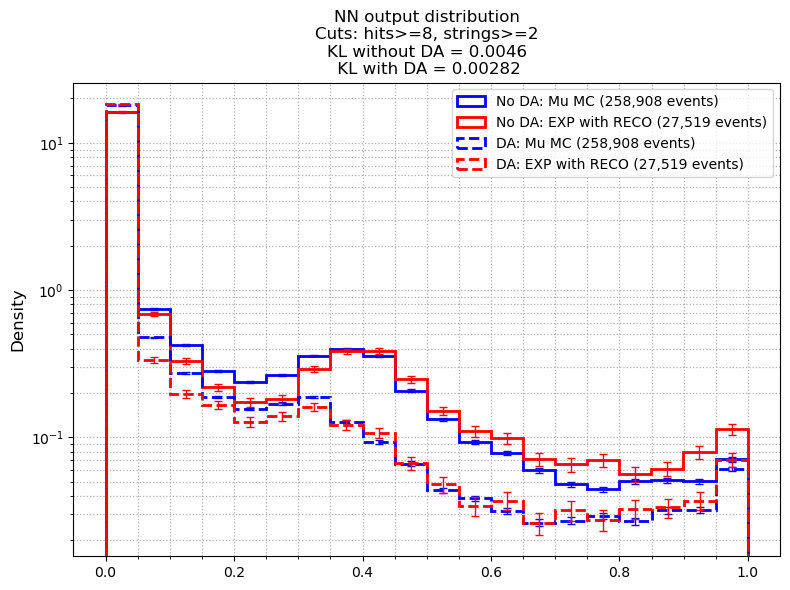

In [43]:
# Pmunu EXP VS MC
## No DA
mc_mask = np.ones(len(mc_probabilities), dtype=bool) & (mc_signal_hit_nums>=8) & (mc_signal_string_nums>=2)
labels_masked, mc_probabilities_masked = mc_labels[mc_mask], mc_probabilities[mc_mask]
exp_mask = np.ones(len(exp_probabilities), dtype=bool)
exp_probas_masked = exp_probabilities[exp_mask]
reco_mask = np.ones(len(reco_probabilities), dtype=bool) & (reco_sig_hits_num >= 8)
reco_probas_masked = reco_probabilities[reco_mask]
## DA
mc_mask_da = np.ones(len(mc_probabilities_da), dtype=bool) & (mc_signal_hit_nums_da>=8) & (mc_signal_string_nums_da>=2)
labels_masked_da, mc_probabilities_masked_da = mc_labels_da[mc_mask_da], mc_probabilities_da[mc_mask_da]
exp_mask_da = np.ones(len(exp_probabilities_da), dtype=bool)
exp_probas_masked_da = exp_probabilities_da[exp_mask_da]
reco_mask_da = np.ones(len(reco_probabilities_da), dtype=bool) & (reco_sig_hits_num_da >= 8)
reco_probas_masked_da = reco_probabilities_da[reco_mask_da]

BINS = 20

# ---------- 1) Common bin edges for both histograms ----------
fig, axs = plt.subplots(1, figsize=(8, 6), sharex=True)
# No DA
all_probs = np.concatenate([
    mc_probabilities_masked[~labels_masked],
    reco_probas_masked
])
bins = np.linspace(all_probs.min(), all_probs.max(), BINS + 1)
## MC (No DA)
counts_mc, bins_mc, patches_mc = axs.hist(
    mc_probabilities_masked[~labels_masked],
    color='b',
    bins=bins,          # use the shared bins
    density=True,
    log=True,
    histtype='step',
    lw=2.,
    label=f'No DA: Mu MC ({sum(mc_mask):,} events)'
)
bin_centers_mc = (bins_mc[:-1] + bins_mc[1:]) / 2
errors_mc = np.sqrt(counts_mc * sum(mc_mask) / BINS) * BINS / sum(mc_mask)
axs.errorbar(
    bin_centers_mc, counts_mc, yerr=errors_mc,
    fmt='none', color='b', capsize=3, capthick=1, elinewidth=1.
)
## EXP (No DA)
counts_exp, bins_exp, patches_exp = axs.hist(
    reco_probas_masked,
    color='red',
    bins=bins,         # use the same bins
    density=True,
    log=True,
    histtype='step',
    lw=2.,
    label=f'No DA: EXP with RECO ({sum(reco_mask):,} events)'
)
bin_centers_exp = (bins_exp[:-1] + bins_exp[1:]) / 2
errors_exp = np.sqrt(counts_exp * sum(reco_mask) / BINS) * BINS / sum(reco_mask)
axs.errorbar(
    bin_centers_exp, counts_exp, yerr=errors_exp,
    fmt='none', color='red', capsize=3, capthick=1, elinewidth=1.
)

# DA
all_probs_da = np.concatenate([
    mc_probabilities_masked_da[~labels_masked_da],
    reco_probas_masked_da
])
bins_da = np.linspace(all_probs_da.min(), all_probs_da.max(), BINS + 1)
## MC (DA)
counts_mc_da, bins_mc_da, patches_mc_da = axs.hist(
    mc_probabilities_masked_da[~labels_masked_da],
    color='b',
    bins=bins_da,          # use the shared bins
    density=True,
    log=True,
    histtype='step',
    lw=2., ls='--',
    label=f'DA: Mu MC ({sum(mc_mask_da):,} events)'
)
bin_centers_mc_da = (bins_mc_da[:-1] + bins_mc_da[1:]) / 2
errors_mc_da = np.sqrt(counts_mc_da * sum(mc_mask_da) / BINS) * BINS / sum(mc_mask_da)
axs.errorbar(
    bin_centers_mc_da, counts_mc_da, yerr=errors_mc_da,
    fmt='none', color='b', capsize=3, capthick=1, elinewidth=1.
)
## EXP (DA)
counts_exp_da, bins_exp_da, patches_exp_da = axs.hist(
    reco_probas_masked_da,
    color='red',
    bins=bins_da,         # use the same bins
    density=True,
    log=True,
    histtype='step',
    lw=2., ls='--',
    label=f'DA: EXP with RECO ({sum(reco_mask_da):,} events)'
)
bin_centers_exp_da = (bins_exp_da[:-1] + bins_exp_da[1:]) / 2
errors_exp_da = np.sqrt(counts_exp_da * sum(reco_mask_da) / BINS) * BINS / sum(reco_mask_da)
axs.errorbar(
    bin_centers_exp_da, counts_exp_da, yerr=errors_exp_da,
    fmt='none', color='red', capsize=3, capthick=1, elinewidth=1.
)

# ---------- 2) KL divergence between the two histograms ----------
## No DA
bin_widths = np.diff(bins)
p = counts_mc * bin_widths
q = counts_exp * bin_widths
eps = 1e-12
p = p + eps
q = q + eps
p /= p.sum()
q /= q.sum()
kl_mc_exp = np.sum(p * np.log(p / q))     # D_KL(MC || EXP)
kl_exp_mc = np.sum(q * np.log(q / p))     # D_KL(EXP || MC), optional
print(f"KL(MC || EXP) = {kl_mc_exp:.6g}")
print(f"KL(EXP || MC) = {kl_exp_mc:.6g}")
## DA
bin_widths = np.diff(bins)
p = counts_mc_da * bin_widths
q = counts_exp_da * bin_widths
eps = 1e-12
p = p + eps
q = q + eps
p /= p.sum()
q /= q.sum()
kl_mc_exp_da = np.sum(p * np.log(p / q))     # D_KL(MC || EXP)
kl_exp_mc_da = np.sum(q * np.log(q / p))     # D_KL(EXP || MC), optional
print(f"DA KL(MC || EXP) = {kl_mc_exp_da:.6g}")
print(f"DA KL(EXP || MC) = {kl_exp_mc_da:.6g}")


axs.set_title(f"NN output distribution\nCuts: hits>=8, strings>=2\nKL without DA = {kl_mc_exp:.3g}\n KL with DA = {kl_mc_exp_da:.3g}")


axs.legend()
axs.grid(which='both', ls=':', lw=0.9)
#axs.set_xlabel("Predicted Nu probability", fontsize=12)
axs.set_ylabel("Density", fontsize=12)
axs.minorticks_on()

plt.tight_layout()
plt.savefig(f"./reco_p_hists_both.png")

In [63]:
bins.shape

(21,)

In [64]:
len(counts_mc)

20